# Train & Analyze — Final Mouse Embedder

`MouseEncoderFinal` (1D-CNN sequence branch + stats MLP → 64-D) trained with **SimCLR NT-Xent** + auxiliary
behavioral-stats regression. Event-count windows (256 events) remove the previous cold-start problem.
Set the config, optionally train, then inspect losses / embeddings / behavioral correlation / gate.

In [1]:
# === CONFIG ===
RUN_TRAINING = False   # True -> launch training; False -> analyze existing checkpoint
EPOCHS     = 100
BATCH_SIZE = 128
LR         = 1e-3
DEVICE     = 'cuda'
W_EVENTS   = 256
import sys, json, subprocess
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt, pandas as pd
ROOT = Path('..').resolve(); sys.path.insert(0, str(ROOT))
EXPORT = ROOT/'pre_embedders/mouse/exports/mouse_encoder_final'
VAL = ROOT/'outputs/embedders/final_validation'
print('export dir:', EXPORT)

export dir: C:\Users\medte\OneDrive\Desktop\Fusion_Model\pre_embedders\mouse\exports\mouse_encoder_final


In [2]:
if RUN_TRAINING:
    cmd = [sys.executable, str(ROOT/'scripts/embedders/train_mouse_final.py'),
           '--data-dir', str(ROOT/'data'), '--epochs', str(EPOCHS),
           '--batch-size', str(BATCH_SIZE), '--lr', str(LR), '--device', DEVICE,
           '--w-events', str(W_EVENTS), '--output-dir', str(EXPORT)]
    print('running:', ' '.join(cmd)); subprocess.run(cmd, check=True, cwd=str(ROOT))
else:
    print('Skipping training (RUN_TRAINING=False). Using existing checkpoint.')

Skipping training (RUN_TRAINING=False). Using existing checkpoint.


## Loss curves

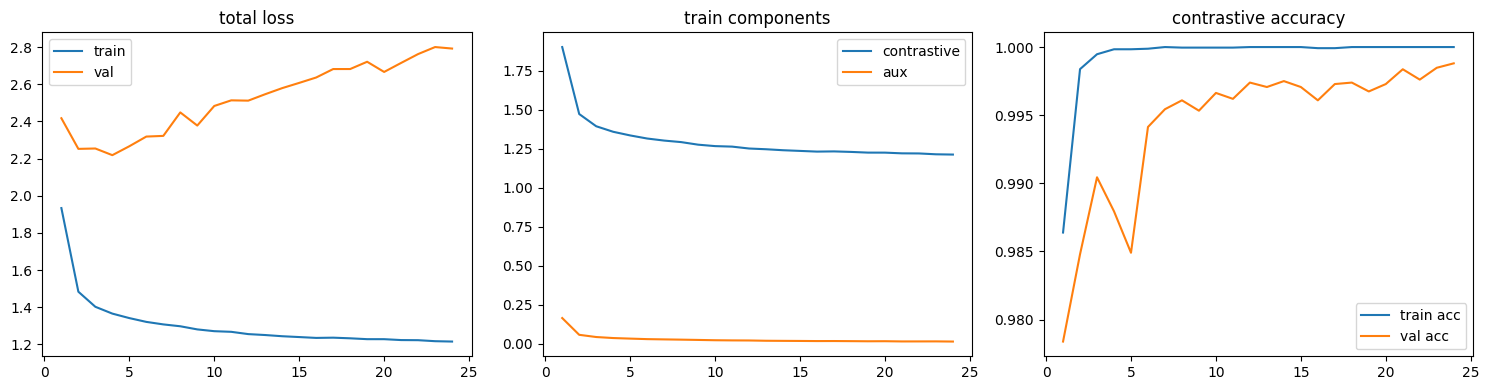

In [3]:
h = pd.read_csv(EXPORT/'loss_history.csv')
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(h['epoch'], h['train_loss'], label='train'); ax[0].plot(h['epoch'], h['val_loss'], label='val')
ax[0].set_title('total loss'); ax[0].legend()
ax[1].plot(h['epoch'], h['train_con'], label='contrastive'); ax[1].plot(h['epoch'], h['train_aux'], label='aux')
ax[1].set_title('train components'); ax[1].legend()
ax[2].plot(h['epoch'], h['train_acc'], label='train acc'); ax[2].plot(h['epoch'], h['val_acc'], label='val acc')
ax[2].set_title('contrastive accuracy'); ax[2].legend()
plt.tight_layout(); plt.show()

## Embedding analysis (norm, PCA colored by behavior)

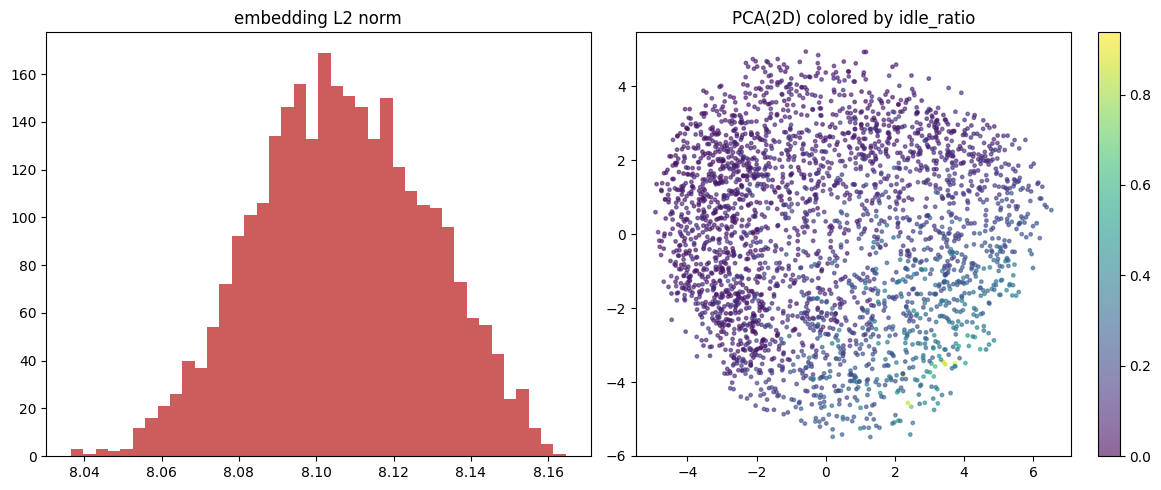

In [4]:
from scripts.embedders import embedder_common as ec
import importlib.util
SEQ, F, sessions, _ = ec.build_mouse_windows(ROOT/'data', max_sessions=20)  # cap for speed
spec = importlib.util.spec_from_file_location('ms_out', EXPORT/'output.py')
mso = importlib.util.module_from_spec(spec); spec.loader.exec_module(mso)
sess = mso.load_model(export_dir=EXPORT, device='cpu')
E = np.stack([mso.get_output(sess, {'seq': SEQ[i], 'stats': F[i]})['embedding'] for i in range(len(SEQ))])
norms = np.linalg.norm(E, axis=1)
Ec = E - E.mean(0); U,S,Vt = np.linalg.svd(Ec, full_matrices=False); pcs = Ec@Vt[:2].T
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].hist(norms, bins=40, color='indianred'); ax[0].set_title('embedding L2 norm')
feat = F[:, ec.MOUSE_FEATURES.index('idle_ratio')]
sc = ax[1].scatter(pcs[:,0], pcs[:,1], c=feat, cmap='viridis', s=6, alpha=0.6)
ax[1].set_title('PCA(2D) colored by idle_ratio'); plt.colorbar(sc, ax=ax[1])
plt.tight_layout(); plt.show()

## Behavioral correlation + validation gate

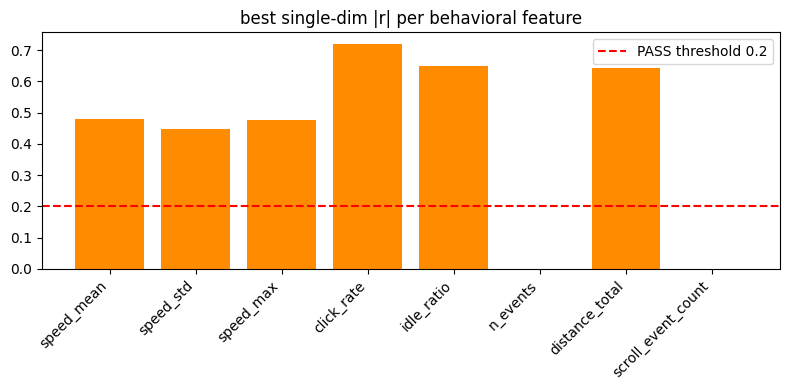

STATUS: PASS | allowed_for_tucker: True
reasons: []
cold_ratio: 0.0 dup: 0.0 n_valid: 16943 tcos: 0.715434324102253


In [5]:
d = json.load(open(VAL/'mouse_validation.json'))
pf = d['behavioral_correlation']['per_feature']
plt.figure(figsize=(8,4)); plt.bar(pf.keys(), pf.values(), color='darkorange')
plt.axhline(0.2, color='r', ls='--', label='PASS threshold 0.2'); plt.legend()
plt.title('best single-dim |r| per behavioral feature'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()
print('STATUS:', d['status'], '| allowed_for_tucker:', d['allowed_for_tucker'])
print('reasons:', d['reasons'])
h=d['health']; print('cold_ratio:', h['cold_start_ratio'], 'dup:', h['duplicate_ratio'],
      'n_valid:', h['n_valid'], 'tcos:', d['temporal_stability']['consecutive_cosine_mean'])